In [1]:
import pandas as pd

In [2]:
df1 = pd.read_excel("D:\Amity UV - My BCA\Semester 6\Major Project (Amity)\E-Commerce Data Cleaning and Reporting\Dataset - 1\Online Retail UK E-Commerce (2009-10).xlsx")
df2 = pd.read_excel("D:\Amity UV - My BCA\Semester 6\Major Project (Amity)\E-Commerce Data Cleaning and Reporting\Dataset - 1\Online Retail UK E-Commerce (2010-11).xlsx")

df = pd.concat([df1, df2], ignore_index=True)

In [3]:
print("="*50)
print("DATASET PROFILE")
print("="*50)

DATASET PROFILE


In [4]:
print("="*50)
print("DATASET PROFILE")
print("="*50)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nCancelled Orders")
print(df['Invoice'].astype(str).str.startswith('C').sum())

print("\nNegative Quantity")
print((df['Quantity'] < 0).sum())

print("\nZero or Negative Price")
print((df['Price'] <= 0).sum())

print("\nUnique Countries")
print(df['Country'].nunique())

print("\nDate Range")
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

DATASET PROFILE
Rows: 1067371
Columns: 8

Missing Values
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate Rows
34335

Cancelled Orders
19494

Negative Quantity
22950

Zero or Negative Price
6207

Unique Countries
43

Date Range
2009-12-01 07:45:00
2011-12-09 12:50:00


### Dropping Duplicates

In [5]:
df = df.drop_duplicates()

### Cleaning Missing Descriptions

In [6]:
df['Description'] = df['Description'].fillna('Unknown Product')

### Updating Missing Customer ID

In [7]:
df['Customer ID'] = df['Customer ID'].fillna(0)

### Managing Cancelled Orders

<div style="padding: 15px; border-left: 5px solid #2196F3; background-color: #E3F2FD; color: #0D47A1; border-radius: 4px;">
    <strong>Note:</strong> 19,494 invoice's begins with: C, which means Cancelled/returned orders. So deal with this lets create two datasets. DATASET(A): Sales Data and DATASET(B): Returns Data
</div>

In [8]:
# Dataset(A): Sales Data
sales_df = df[
    ~df['Invoice'].astype(str).str.startswith('C')
]

In [9]:
# Dataset(B): Returns Data
returns_df = df[
    df['Invoice'].astype(str).str.startswith('C')
]

<div style="padding: 15px; border-left: 5px solid #4CAF50; background-color: #E8F5E9; color: #1B5E20; border-radius: 4px;">
    <strong>Success:</strong> We created seperate datasets as business wants: Actual Sales, Returns Analysis separately.
</div>

In [10]:
negative_qty = df[df['Quantity'] < 0]

print(
    negative_qty['Invoice']
    .astype(str)
    .str.startswith('C')
    .value_counts()
)

Invoice
True     19103
False     3393
Name: count, dtype: int64


In [11]:
negative_non_cancel = df[
    (df['Quantity'] < 0)
    &
    (~df['Invoice'].astype(str).str.startswith('C'))
]

negative_non_cancel[
    ['Invoice',
     'StockCode',
     'Description',
     'Quantity',
     'Price']
].head(50)

,Invoice,StockCode,Description,Quantity,Price
263,489464,21733,85123a mixed,-96,0.0
283,489463,71477,short,-240,0.0
284,489467,85123A,21733 mixed,-192,0.0
470,489521,21646,Unknown Product,-50,0.0
3114,489655,20683,Unknown Product,-44,0.0
3162,489660,35956,lost,-1043,0.0
3168,489663,35605A,damages,-117,0.0
4296,489806,18010,Unknown Product,-770,0.0
4538,489820,21133,invcd as 84879?,-720,0.0
4566,489821,85049G,Unknown Product,-240,0.0


In [12]:
import numpy as np

df['TransactionType'] = np.where(
    df['Invoice'].astype(str).str.startswith('C'),
    'Customer Return',
    np.where(
        (df['Quantity'] < 0) &
        (df['Price'] == 0),
        'Inventory Adjustment',
        'Sales'
    )
)

In [13]:
df['TransactionType'].value_counts()

TransactionType
Sales                   1010539
Customer Return           19104
Inventory Adjustment       3393
Name: count, dtype: int64

In [14]:
sales_df = df[
    (df['TransactionType'] == 'Sales')
    &
    (df['Quantity'] > 0)
    &
    (df['Price'] > 0)
].copy()

### Creating Revenue Column:

In [15]:
sales_df['Revenue'] = (
    sales_df['Quantity']
    * sales_df['Price']
)

In [16]:
sales_df.shape

sales_df.isnull().sum()

sales_df.duplicated().sum()

(sales_df['Quantity'] <= 0).sum()

(sales_df['Price'] <= 0).sum()

np.int64(0)

In [17]:
print("Rows:", sales_df.shape[0])

print("Columns:", sales_df.shape[1])

print("Total Revenue:",
      sales_df['Revenue'].sum())

print("Unique Customers:",
      sales_df['Customer ID'].nunique())

print("Unique Products:",
      sales_df['StockCode'].nunique())

print("Countries:",
      sales_df['Country'].nunique())

print("Date Range:")
print(sales_df['InvoiceDate'].min())
print(sales_df['InvoiceDate'].max())

Rows: 1007913
Columns: 10
Total Revenue: 20476260.447999995
Unique Customers: 5879
Unique Products: 4917
Countries: 43
Date Range:
2009-12-01 07:45:00
2011-12-09 12:50:00


In [18]:
sales_df['InvoiceDate'] = pd.to_datetime(
    sales_df['InvoiceDate']
)

In [19]:
sales_df['Year'] = sales_df['InvoiceDate'].dt.year

sales_df['Month'] = sales_df['InvoiceDate'].dt.month

sales_df['MonthName'] = sales_df['InvoiceDate'].dt.strftime('%B')

In [20]:
sales_df.to_csv(
    'online_retail_cleaned.csv',
    index=False
)

In [21]:
print(sales_df.shape)

print(sales_df.isnull().sum())

print(sales_df.duplicated().sum())

print((sales_df['Quantity'] <= 0).sum())

print((sales_df['Price'] <= 0).sum())

(1007913, 13)
Invoice            0
StockCode          0
Description        0
Quantity           0
InvoiceDate        0
Price              0
Customer ID        0
Country            0
TransactionType    0
Revenue            0
Year               0
Month              0
MonthName          0
dtype: int64
0
0
0


In [23]:
sales_df.shape

sales_df['Revenue'].sum()

sales_df['Customer ID'].nunique()

sales_df['Country'].nunique()

sales_df['Description'].nunique()

5399

### Creating Analysis Feilds

In [25]:
sales_df['Year'] = sales_df['InvoiceDate'].dt.year

sales_df['Month'] = sales_df['InvoiceDate'].dt.month

sales_df['MonthName'] = sales_df['InvoiceDate'].dt.strftime('%B')

sales_df['YearMonth'] = sales_df['InvoiceDate'].dt.to_period('M')

#### Revenue by Year:

In [26]:
yearly_revenue = (
    sales_df
    .groupby('Year')['Revenue']
    .sum()
    .reset_index()
)

print(yearly_revenue)

   Year      Revenue
0  2009   822483.950
1  2010  9833100.424
2  2011  9820676.074


#### Revenue By Month:

In [27]:
monthly_revenue = (
    sales_df
    .groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)

monthly_revenue = monthly_revenue.sort_values('YearMonth')

print(monthly_revenue.head())

  YearMonth     Revenue
0   2009-12  822483.950
1   2010-01  651155.112
2   2010-02  551504.726
3   2010-03  830915.261
4   2010-04  678875.252


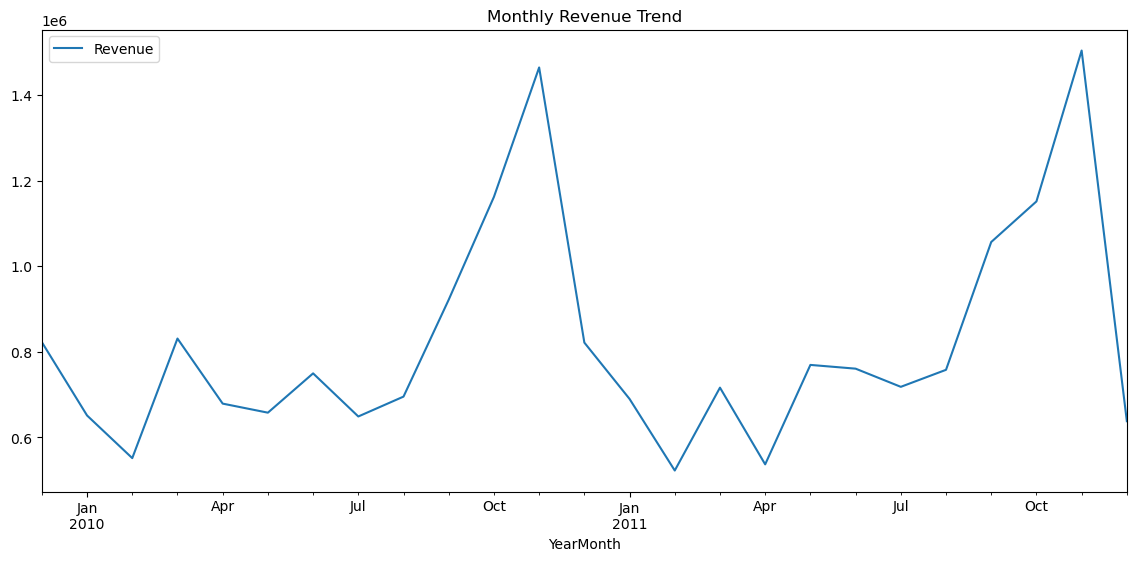

In [28]:
import matplotlib.pyplot as plt

monthly_revenue.plot(
    x='YearMonth',
    y='Revenue',
    figsize=(14,6)
)

plt.title('Monthly Revenue Trend')
plt.show()

#### Top 10 Countries by Revenue:

In [29]:
country_revenue = (
    sales_df
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_revenue)

Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64


#### Top 10 Products by Revenue:

In [30]:
top_products = (
    sales_df
    .groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64


#### Top 10 Products by Quantity Sold:

In [31]:
top_quantity_products = (
    sales_df
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_quantity_products)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: Quantity, dtype: int64


#### Top Customers by Revenue:

In [32]:
top_customers = (
    sales_df
    .groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer ID
0.0        3101456.18
18102.0     580987.04
14646.0     528602.52
14156.0     313437.62
14911.0     291420.81
17450.0     244784.25
13694.0     195640.69
17511.0     172132.87
16446.0     168472.50
16684.0     147142.77
Name: Revenue, dtype: float64


#### Revenue by Country:

In [33]:
country_summary = (
    sales_df
    .groupby('Country')
    .agg(
        Revenue=('Revenue','sum'),
        Orders=('Invoice','nunique'),
        Customers=('Customer ID','nunique')
    )
    .sort_values(
        'Revenue',
        ascending=False
    )
)

print(country_summary.head(10))

                     Revenue  Orders  Customers
Country                                        
United Kingdom  1.741020e+07   36535       5351
EIRE            6.587673e+05     626          6
Netherlands     5.540381e+05     228         22
Germany         4.250197e+05     789        107
France          3.504561e+05     622         96
Australia       1.692835e+05      95         15
Spain           1.083325e+05     154         41
Switzerland     1.006856e+05      93         23
Sweden          9.186982e+04     105         20
Denmark         6.858069e+04      43         12


#### Average Order Value:

In [34]:
total_revenue = sales_df['Revenue'].sum()

total_orders = sales_df['Invoice'].nunique()

aov = total_revenue / total_orders

print("Average Order Value:", round(aov,2))

Average Order Value: 510.92


#### Customer Purchase Frequency:

In [35]:
customer_frequency = (
    sales_df
    .groupby('Customer ID')['Invoice']
    .nunique()
)

print(customer_frequency.describe())

count    5879.000000
mean        6.816976
std        42.492965
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max      3108.000000
Name: Invoice, dtype: float64


#### Monthly Orders Trend:

In [36]:
monthly_orders = (
    sales_df
    .groupby('YearMonth')['Invoice']
    .nunique()
    .reset_index()
)

print(monthly_orders.head())

  YearMonth  Invoice
0   2009-12     1682
1   2010-01     1105
2   2010-02     1201
3   2010-03     1681
4   2010-04     1462


## RFM Customer Segmentation Analysis

#### Create RFM Base Dataset:

In [37]:
import pandas as pd

analysis_date = pd.Timestamp('2011-12-10')

In [54]:
rfm_source = sales_df[
    sales_df['Customer ID'] != 0
].copy()

#### Create RFM table:

In [55]:
rfm = sales_df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

#### Rename Columns:

In [56]:
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

#### Check Results:

In [57]:
print(rfm.head())

   CustomerID  Recency  Frequency    Monetary
0         0.0        0       3108  3101456.18
1     12346.0      325         12    77556.46
2     12347.0        2          8     4921.53
3     12348.0       75          5     2019.40
4     12349.0       18          4     4428.69


#### Explore RFM Metrics:

In [58]:
print(rfm.describe())

         CustomerID      Recency    Frequency      Monetary
count   5879.000000  5879.000000  5879.000000  5.879000e+03
mean   15312.708454   200.832625     6.816976  3.482950e+03
std     1727.016677   209.352543    42.492965  4.291332e+04
min        0.000000     0.000000     1.000000  2.950000e+00
25%    13832.500000    25.000000     1.000000  3.423200e+02
50%    15314.000000    95.000000     3.000000  8.683700e+02
75%    16797.500000   379.000000     7.000000  2.249010e+03
max    18287.000000   738.000000  3108.000000  3.101456e+06


#### Create RFM Scores:

In [59]:
# Recency Score: Smaller = Better
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

In [44]:
# Fequency Score: Higher = Better
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [45]:
# Monetary Score: Higher = Better
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

#### Create Combined RFM Score:

In [46]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    +
    rfm['F_Score'].astype(str)
    +
    rfm['M_Score'].astype(str)
)

#### Create Customer Segments:

In [47]:
def segment_customer(row):

    if row['RFM_Score'] == '555':
        return 'Champions'

    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4:
        return 'Potential Loyalists'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 4:
        return 'At Risk'

    else:
        return 'Others'

In [48]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

#### View Segment Distribution:

In [49]:
segment_summary = (
    rfm['Segment']
    .value_counts()
)

print(segment_summary)

Segment
Others                 3169
Loyal Customers        1004
Potential Loyalists     879
Champions               473
At Risk                 354
Name: count, dtype: int64


#### Revenue By Segment:

In [50]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Segment
Champions              1.129405e+07
Loyal Customers        3.808792e+06
Others                 3.411744e+06
At Risk                1.091695e+06
Potential Loyalists    8.699795e+05
Name: Monetary, dtype: float64


### Final Visualization:

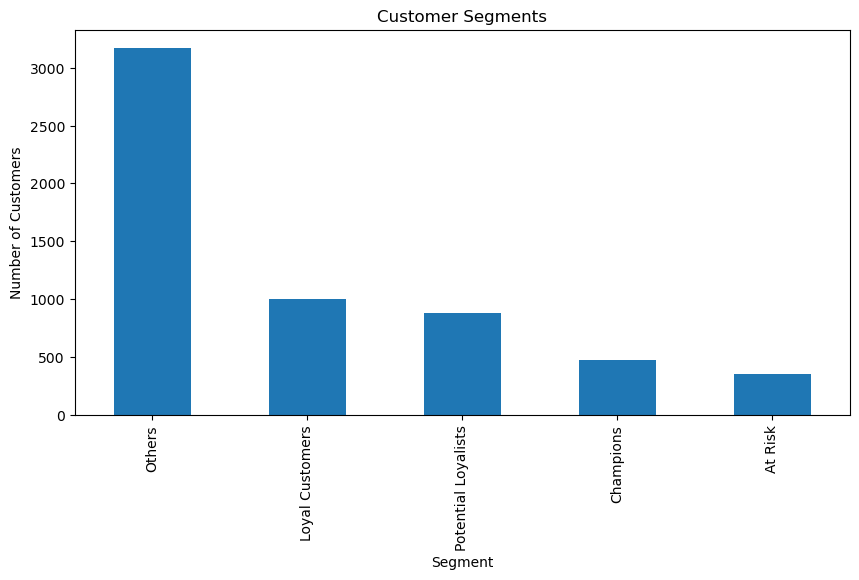

In [51]:
import matplotlib.pyplot as plt

segment_summary.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Customer Segments')
plt.ylabel('Number of Customers')
plt.show()

In [52]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5879.000000,5879.000000,5879.000000,5.879000e+03
mean,15312.708454,200.832625,6.816976,3.482950e+03
std,1727.016677,209.352543,42.492965,4.291332e+04
min,0.000000,0.000000,1.000000,2.950000e+00
25%,13832.500000,25.000000,1.000000,3.423200e+02
50%,15314.000000,95.000000,3.000000,8.683700e+02
75%,16797.500000,379.000000,7.000000,2.249010e+03
max,18287.000000,738.000000,3108.000000,3.101456e+06


In [53]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,0.0,0,3108,3101456.18,5,5,5,555,Champions
1,12346.0,325,12,77556.46,2,5,5,255,At Risk
2,12347.0,2,8,4921.53,5,4,5,545,Loyal Customers
3,12348.0,75,5,2019.40,3,4,4,344,Others
4,12349.0,18,4,4428.69,5,3,5,535,Potential Loyalists
5,12350.0,310,1,334.40,2,1,2,212,Others
6,12351.0,375,1,300.93,2,1,2,212,Others
7,12352.0,36,10,2849.84,4,5,4,454,Loyal Customers
8,12353.0,204,2,406.76,2,2,2,222,Others
9,12354.0,232,1,1079.40,2,1,3,213,Others


Exporting Cleaned Sales Dataset

In [60]:
sales_df.to_csv(
    "Sales_Cleaned.csv",
    index=False
)

## RFM Re-Run:

In [61]:
rfm_source = sales_df[
    sales_df['Customer ID'] != 0
].copy()

In [62]:
print("Total Customers Before:",
      sales_df['Customer ID'].nunique())

print("Total Customers After:",
      rfm_source['Customer ID'].nunique())

Total Customers Before: 5879
Total Customers After: 5878


In [63]:
import pandas as pd

analysis_date = pd.Timestamp('2011-12-10')

In [64]:
rfm = rfm_source.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

In [65]:
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

In [66]:
print(rfm.head())
print(rfm.shape)

   CustomerID  Recency  Frequency  Monetary
0     12346.0      325         12  77556.46
1     12347.0        2          8   4921.53
2     12348.0       75          5   2019.40
3     12349.0       18          4   4428.69
4     12350.0      310          1    334.40
(5878, 4)


In [67]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

In [68]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [69]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [70]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    +
    rfm['F_Score'].astype(str)
    +
    rfm['M_Score'].astype(str)
)

In [71]:
def segment_customer(row):

    if row['RFM_Score'] == '555':
        return 'Champions'

    elif int(row['R_Score']) >= 4 and int(row['F_Score']) >= 4:
        return 'Loyal Customers'

    elif int(row['R_Score']) >= 4:
        return 'Potential Loyalists'

    elif int(row['R_Score']) <= 2 and int(row['F_Score']) >= 4:
        return 'At Risk'

    else:
        return 'Others'

In [72]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

In [73]:
segment_summary = (
    rfm['Segment']
    .value_counts()
)

print(segment_summary)

Segment
Others                 3171
Loyal Customers        1003
Potential Loyalists     879
Champions               473
At Risk                 352
Name: count, dtype: int64


In [74]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Segment
Champions              8195505.044
Loyal Customers        3805881.351
Others                 3413425.330
At Risk                1090013.012
Potential Loyalists     869979.531
Name: Monetary, dtype: float64


In [75]:
segment_percentage = (
    segment_revenue
    /
    segment_revenue.sum()
    * 100
)

print(segment_percentage.round(2))

Segment
Champions              47.17
Loyal Customers        21.90
Others                 19.65
At Risk                 6.27
Potential Loyalists     5.01
Name: Monetary, dtype: float64


In [76]:
rfm.to_csv(
    "Customer_RFM_Final.csv",
    index=False
)

In [77]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,200.866791,6.289384,2955.904095
std,1715.572666,209.353961,13.009406,14440.852688
min,12346.000000,0.000000,1.000000,2.950000
25%,13833.250000,25.000000,1.000000,342.280000
50%,15314.500000,95.000000,3.000000,867.740000
75%,16797.750000,379.000000,7.000000,2248.305000
max,18287.000000,738.000000,398.000000,580987.040000


In [78]:
# Revenue Share of UK

uk_share = (
    sales_df[sales_df['Country'] == 'United Kingdom']
    ['Revenue']
    .sum()
    /
    sales_df['Revenue'].sum()
) * 100

print(round(uk_share,2))

85.03


In [79]:
# Top 10 Product Revenue Share

top10_share = (
    sales_df
    .groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sum()
    /
    sales_df['Revenue'].sum()
) * 100

print(round(top10_share,2))

10.15
